# Dependency Parsing 

In [2]:
import spacy
from spacy import displacy
import conllu
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Load mô hình pre-trained của tiếng Anh
# Mô hình này dưới nền tảng sử dụng Neural Transition-based parser
nlp = spacy.load("en_core_web_sm")

# Phân tích cú pháp phụ thuộc cơ bản 

In [3]:
# Lấy ví dụ câu kinh điển trong sách (Figure 19.15)
sentence = "Book me the morning flight through Houston."
doc = nlp(sentence)

print(f"{'TOKEN':<12} | {'POS':<6} | {'HEAD':<12} | {'DEPENDENCY RELATION (Arc)'}")
print("-" * 55)
for token in doc:
    # token.text: từ hiện tại (Dependent)
    # token.pos_: Từ loại (Part of Speech)
    # token.head.text: Từ gốc (Head)
    # token.dep_: Loại quan hệ phụ thuộc (Universal Dependency tag)
    print(f"{token.text:<12} | {token.pos_:<6} | {token.head.text:<12} | {token.dep_}")

TOKEN        | POS    | HEAD         | DEPENDENCY RELATION (Arc)
-------------------------------------------------------
Book         | VERB   | Book         | ROOT
me           | PRON   | Book         | dobj
the          | DET    | flight       | det
morning      | NOUN   | flight       | compound
flight       | NOUN   | Book         | dobj
through      | ADP    | flight       | prep
Houston      | PROPN  | through      | pobj
.            | PUNCT  | Book         | punct


# Trực quan hoá cây phụ thuộc

In [4]:
# Sử dụng displacy để vẽ cây phụ thuộc. 
displacy.render(doc, style="dep", jupyter=True, options={"distance": 100})

# Đọc Real Dataset

In [5]:
!wget https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-test.conllu -O en_ewt-ud-test.conllu

print("\nĐã tải xong file dataset: en_ewt-ud-test.conllu")

file_path = "en_ewt-ud-test.conllu"

with open(file_path, "r", encoding="utf-8") as f:
    data = f.read()

# Parse file CoNLL-U
sentences = conllu.parse(data)
print(f"Đã load thành công {len(sentences)} câu từ dataset gốc.\n")

# Hiển thị thử câu đầu tiên và các nhãn (Gold Standard Label)
sample_sentence = sentences[0]
print("Câu mẫu:", sample_sentence.metadata['text'])
print(f"{'TOKEN':<15} | {'HEAD ID':<8} | {'DEPENDENCY'}")
print("-" * 40)
for token in sample_sentence:
    # Trong định dạng CoNLL, head là một ID (chỉ mục số nguyên) trỏ đến từ gốc trong câu
    print(f"{token['form']:<15} | {token['head']:<8} | {token['deprel']}")

--2026-05-19 01:52:13--  https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-test.conllu
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1900101 (1.8M) [text/plain]
Saving to: ‘en_ewt-ud-test.conllu’

en_ewt-ud-test.conl 100%[===================>]   1.81M  --.-KB/s    in 0.03s   

2026-05-19 01:52:13 (71.1 MB/s) - ‘en_ewt-ud-test.conllu’ saved [1900101/1900101]


Đã tải xong file dataset: en_ewt-ud-test.conllu
Đã load thành công 2077 câu từ dataset gốc.

Câu mẫu: What if Google Morphed Into GoogleOS?
TOKEN           | HEAD ID  | DEPENDENCY
----------------------------------------
What            | 0        | root
if              | 4        | mark
Google          | 4        | nsubj
Morphed         | 1        | advcl
Into   

# Đánh giá Parser với UAS và LAS

In [6]:
# Hàm tính toán UAS (Unlabeled Attachment Score) và LAS (Labeled Attachment Score)
# Căn cứ theo mục 19.4 Evaluation trong tài liệu
def evaluate_parser(gold_sentences, nlp_model, max_sentences=500):
    correct_unlabeled = 0 # Đúng Head (UAS)
    correct_labeled = 0   # Đúng Head và đúng Label (LAS)
    total_tokens = 0
    
    for i, gold_sent in enumerate(gold_sentences[:max_sentences]):
        text = gold_sent.metadata['text']
        doc = nlp_model(text)
        
        # Để dễ so sánh trong demo, chỉ đánh giá các câu mà tokenizer 
        # của spaCy và của CoNLL-U chia ra số lượng token giống nhau
        if len(doc) != len(gold_sent):
            continue
            
        for spacy_token, gold_token in zip(doc, gold_sent):
            # Bỏ qua root node ảo (ID = 0 trong CoNLL)
            if gold_token['head'] == 0:
                continue
                
            total_tokens += 1
            
            # Lấy Head ID dự đoán của spaCy (chuyển index từ 0-based sang 1-based của CoNLL)
            predicted_head_id = spacy_token.head.i + 1 
            gold_head_id = gold_token['head']
            
            # Chuẩn hoá label về chữ thường để so sánh
            predicted_dep = spacy_token.dep_.lower()
            gold_dep = gold_token['deprel'].lower().split(":")[0] # Loại bỏ subtype để dễ khớp
            
            # Đánh giá UAS
            if predicted_head_id == gold_head_id:
                correct_unlabeled += 1
                # Đánh giá LAS
                if predicted_dep == gold_dep:
                    correct_labeled += 1

    if total_tokens == 0:
        return 0, 0
        
    uas = correct_unlabeled / total_tokens
    las = correct_labeled / total_tokens
    return uas, las

if sentences:
    print("Đang đánh giá mô hình spaCy trên 500 câu đầu tiên của tập Test...")
    uas_score, las_score = evaluate_parser(sentences, nlp, max_sentences=500)
    print(f"\nKết quả đánh giá (Evaluation - Mục 19.4):")
    print(f"UAS (Unlabeled Attachment Score): {uas_score:.2%}")
    print(f"LAS (Labeled Attachment Score): {las_score:.2%}")

Đang đánh giá mô hình spaCy trên 500 câu đầu tiên của tập Test...

Kết quả đánh giá (Evaluation - Mục 19.4):
UAS (Unlabeled Attachment Score): 53.13%
LAS (Labeled Attachment Score): 39.21%


# Biểu diễn Dependency Parsing dưới dạng Đồ thị Graph-based

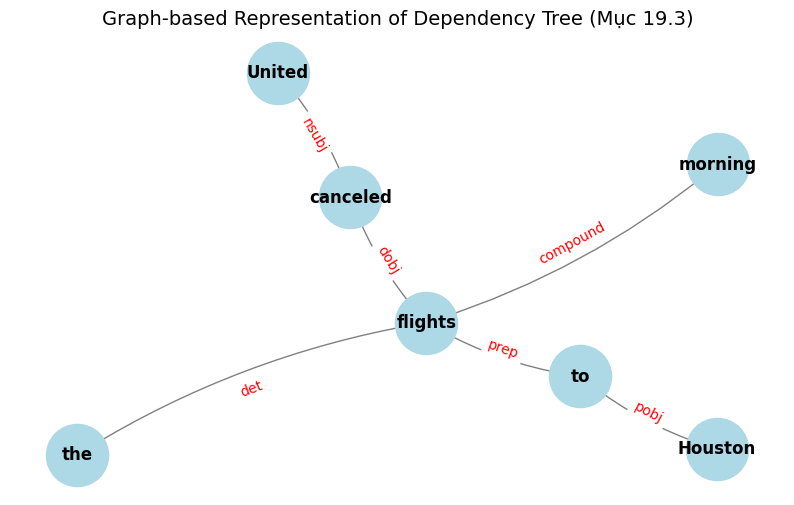

In [7]:
# Dưới đây là cách mô hình hoá câu thành đồ thị có hướng (Directed Graph) sử dụng NetworkX

text = "United canceled the morning flights to Houston" # Ví dụ 19.2 trong sách
doc = nlp(text)

G = nx.DiGraph()

# Thêm các Node và Edge dựa vào Dependency
for token in doc:
    # Node đại diện cho từ
    G.add_node(token.text)
    
    # Edge đại diện cho Arc từ Head -> Dependent (để biểu diễn cây spanning tree)
    if token.dep_ != "ROOT":
        G.add_edge(token.head.text, token.text, label=token.dep_)

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42) # Layout tự do

# Vẽ nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Vẽ edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20, connectionstyle='arc3, rad=0.1')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title("Graph-based Representation of Dependency Tree (Mục 19.3)", fontsize=14)
plt.axis('off')
plt.show()